In [ ]:
import numpy as np
import pandas as pd


np.random.seed(42)


n = 1000


timestamps = pd.date_range(
    start="2026-01-01 00:00:00",
    periods=n,
    freq="min"
)


cpu = np.random.normal(45, 10, n)
memory = np.random.normal(55, 8, n)
disk = np.random.normal(40, 10, n)
network = np.random.normal(30, 8, n)
processes = np.random.normal(100, 15, n)


cpu = np.clip(cpu, 5, 90)
memory = np.clip(memory, 10, 90)
disk = np.clip(disk, 5, 90)
network = np.clip(network, 5, 90)
processes = np.clip(processes, 30, 180)


anomaly = np.zeros(n)


cpu_anomaly_indices = [150, 300, 450, 600, 750]
cpu[cpu_anomaly_indices] = [97, 95, 99, 96, 98]
anomaly[cpu_anomaly_indices] = 1


memory_anomaly_indices = [200, 400, 500, 700, 850]
memory[memory_anomaly_indices] = [92, 94, 96, 95, 98]
anomaly[memory_anomaly_indices] = 1


combined_indices = [250, 550, 900]
cpu[combined_indices] = [96, 99, 97]
memory[combined_indices] = [94, 97, 96]
anomaly[combined_indices] = 1


df = pd.DataFrame({
    "timestamp": timestamps,
    "cpu_usage": cpu,
    "memory_usage": memory,
    "disk_usage": disk,
    "network_usage": network,
    "active_processes": processes,
    "anomaly": anomaly.astype(int)
})


df.to_csv("server_load_dataset.csv", index=False)


print("Dataset created successfully!")
print("Dataset shape:", df.shape)
print("\nFirst 10 records:")
display(df.head(10))

print("\nNumber of anomalies:", df["anomaly"].sum())
print("Number of normal records:", (df["anomaly"] == 0).sum())

Dataset created successfully!
Dataset shape: (1000, 7)

First 10 records:


,timestamp,cpu_usage,memory_usage,disk_usage,network_usage,active_processes,anomaly
0,2026-01-01 00:00:00,49.967142,66.194843,33.248217,14.737540,87.047596,0
1,2026-01-01 00:01:00,43.617357,62.397069,38.554813,23.116920,99.531948,0
2,2026-01-01 00:02:00,51.476885,55.477043,32.075801,26.691156,100.270253,0
3,2026-01-01 00:03:00,60.230299,49.824506,36.920385,45.101501,107.089455,0
4,2026-01-01 00:04:00,42.658466,60.585787,21.063853,34.452425,79.497125,0
5,2026-01-01 00:05:00,42.658630,58.147883,42.132937,19.316147,108.888509,0
6,2026-01-01 00:06:00,60.792128,62.161546,40.012055,33.888290,59.434126,0
7,2026-01-01 00:07:00,52.674347,60.081374,31.829114,17.621568,90.551732,0
8,2026-01-01 00:08:00,40.305256,63.396422,46.592457,38.661528,92.675892,0
9,2026-01-01 00:09:00,50.425600,50.718118,49.375701,26.231003,109.499902,0



Number of anomalies: 13
Number of normal records: 987


In [ ]:
# Basic information
print("Dataset Information:")
print(df.info())

# Statistical summary
print("\nStatistical Summary:")
display(df.describe())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Count normal and anomalous records
print("\nClass Distribution:")
print(df["anomaly"].value_counts())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   timestamp         1000 non-null   datetime64[ns]
 1   cpu_usage         1000 non-null   float64       
 2   memory_usage      1000 non-null   float64       
 3   disk_usage        1000 non-null   float64       
 4   network_usage     1000 non-null   float64       
 5   active_processes  1000 non-null   float64       
 6   anomaly           1000 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 54.8 KB
None

Statistical Summary:


,timestamp,cpu_usage,memory_usage,disk_usage,network_usage,active_processes,anomaly
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2026-01-01 08:19:29.999999744,45.626451,55.884780,40.058342,29.850246,99.260895,0.013000
min,2026-01-01 00:00:00,12.587327,31.476891,9.804878,6.564410,52.349443,0.000000
25%,2026-01-01 04:09:45,38.625247,50.175497,33.520004,24.100636,89.760926,0.000000
50%,2026-01-01 08:19:30,45.292505,55.551631,39.997492,30.001477,99.726370,0.000000
75%,2026-01-01 12:29:15,51.640161,60.994145,46.609153,35.335563,109.586847,0.000000
max,2026-01-01 16:39:00,99.000000,98.000000,79.262377,55.944744,146.693653,1.000000
std,NaN,10.812589,8.719402,9.834543,8.217060,14.885703,0.113331



Missing Values:
timestamp           0
cpu_usage           0
memory_usage        0
disk_usage          0
network_usage       0
active_processes    0
anomaly             0
dtype: int64

Class Distribution:
anomaly
0    987
1     13
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler

# Select features for anomaly detection
features = [
    "cpu_usage",
    "memory_usage",
    "disk_usage",
    "network_usage",
    "active_processes"
]

X = df[features]

# Store actual labels separately for evaluation
y_true = df["anomaly"]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features selected:")
print(features)

print("\nOriginal data shape:", X.shape)
print("Scaled data shape:", X_scaled.shape)

print("\nFirst 5 scaled records:")
print(X_scaled[:5])

Features selected:
['cpu_usage', 'memory_usage', 'disk_usage', 'network_usage', 'active_processes']

Original data shape: (1000, 5)
Scaled data shape: (1000, 5)

First 5 scaled records:
[[ 0.4016487   1.18301946 -0.6928164  -1.84010685 -0.82088233]
 [-0.1859036   0.74724712 -0.15295893 -0.81984254  0.01821801]
 [ 0.5413469  -0.04678542 -0.81209018 -0.38464745  0.06784112]
 [ 1.35130952 -0.69538098 -0.31923473  1.85697634  0.52617447]
 [-0.27463078  0.539413   -1.9323718   0.56035631 -1.32836588]]


In [ ]:
from sklearn.svm import OneClassSVM

# Create One-Class SVM model
model = OneClassSVM(
    kernel="rbf",
    gamma="auto",
    nu=0.02
)

# Train the model
model.fit(X_scaled)

# Predict anomalies
predictions = model.predict(X_scaled)

# Convert predictions:
# 1  = normal
# -1 = anomaly
predicted_anomaly = (predictions == -1).astype(int)

print("One-Class SVM completed successfully!")

print("\nPredicted normal records:",
      (predicted_anomaly == 0).sum())

print("Predicted anomaly records:",
      (predicted_anomaly == 1).sum())

One-Class SVM completed successfully!

Predicted normal records: 961
Predicted anomaly records: 39


Confusion Matrix:
[[955  32]
 [  6   7]]


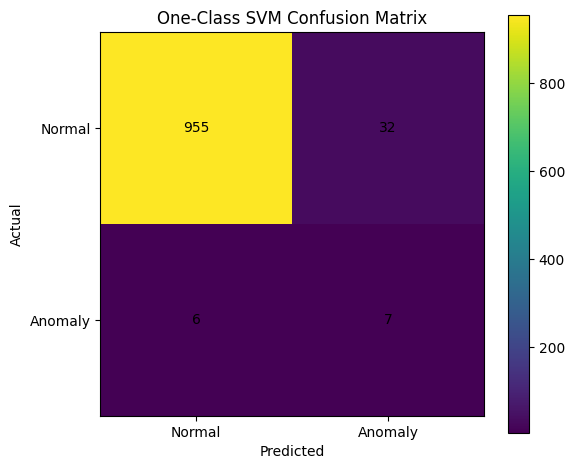

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_true, predicted_anomaly)

# Display values
print("Confusion Matrix:")
print(cm)

# Matplotlib-only visualization
plt.figure(figsize=(6, 5))

plt.imshow(cm, interpolation="nearest")
plt.title("One-Class SVM Confusion Matrix")
plt.colorbar()

# Axis labels
plt.xticks([0, 1], ["Normal", "Anomaly"])
plt.yticks([0, 1], ["Normal", "Anomaly"])

plt.xlabel("Predicted")
plt.ylabel("Actual")

# Add numbers inside the matrix
for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

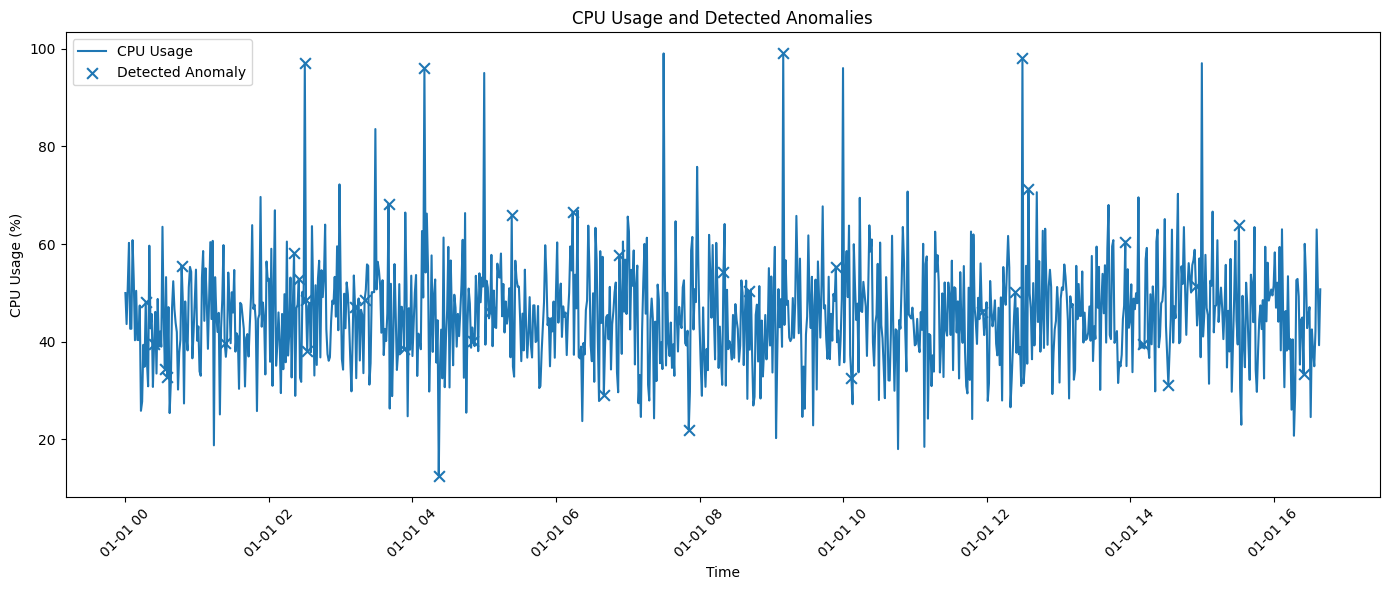

In [ ]:
import matplotlib.pyplot as plt

# Create a copy of the dataset
results = df.copy()

# Add model predictions
results["predicted_anomaly"] = predicted_anomaly

# Plot CPU usage
plt.figure(figsize=(14, 6))

# Plot all CPU usage
plt.plot(
    results["timestamp"],
    results["cpu_usage"],
    label="CPU Usage"
)

# Highlight predicted anomalies
anomaly_data = results[results["predicted_anomaly"] == 1]

plt.scatter(
    anomaly_data["timestamp"],
    anomaly_data["cpu_usage"],
    label="Detected Anomaly",
    marker="x",
    s=60
)

plt.title("CPU Usage and Detected Anomalies")
plt.xlabel("Time")
plt.ylabel("CPU Usage (%)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

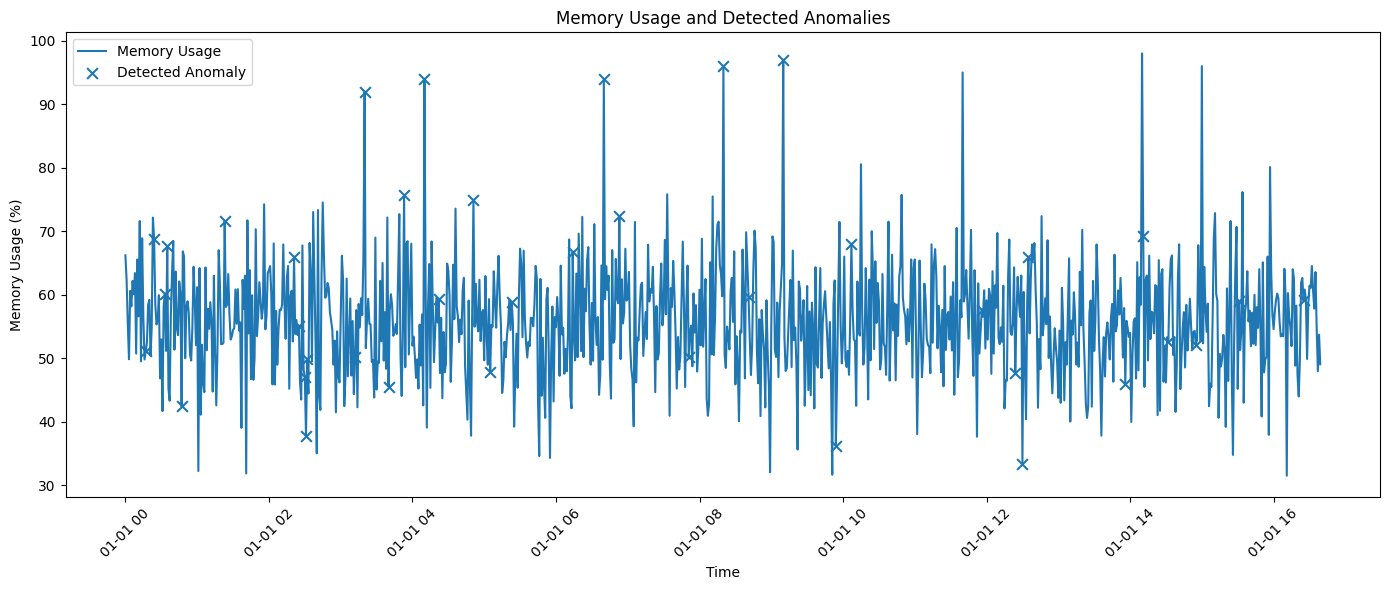

In [ ]:
plt.figure(figsize=(14, 6))

# Plot memory usage
plt.plot(
    results["timestamp"],
    results["memory_usage"],
    label="Memory Usage"
)

# Highlight predicted anomalies
plt.scatter(
    anomaly_data["timestamp"],
    anomaly_data["memory_usage"],
    label="Detected Anomaly",
    marker="x",
    s=60
)

plt.title("Memory Usage and Detected Anomalies")
plt.xlabel("Time")
plt.ylabel("Memory Usage (%)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate anomaly scores
results["anomaly_score"] = model.decision_function(X_scaled)

# Lower scores indicate more unusual observations
print("Anomaly Score Statistics:")
print(results["anomaly_score"].describe())

# Display the 10 most anomalous records
most_anomalous = results.sort_values(
    "anomaly_score"
).head(10)

print("\nTop 10 Most Anomalous Records:")
display(
    most_anomalous[
        [
            "timestamp",
            "cpu_usage",
            "memory_usage",
            "disk_usage",
            "network_usage",
            "active_processes",
            "anomaly_score",
            "anomaly",
            "predicted_anomaly"
        ]
    ]
)

Anomaly Score Statistics:
count    1000.000000
mean        0.288048
std         0.148124
min        -0.000410
25%         0.188585
50%         0.318380
75%         0.412604
max         0.511246
Name: anomaly_score, dtype: float64

Top 10 Most Anomalous Records:


,timestamp,cpu_usage,memory_usage,disk_usage,network_usage,active_processes,anomaly_score,anomaly,predicted_anomaly
200,2026-01-01 03:20:00,48.577874,92.000000,58.043481,31.481404,103.654858,-0.000410,1,1
400,2026-01-01 06:40:00,29.055723,94.000000,32.782624,33.931436,107.309579,-0.000397,1,1
744,2026-01-01 12:24:00,50.176590,47.581175,14.704399,22.038812,124.065087,-0.000384,0,1
83,2026-01-01 01:23:00,39.817298,71.613984,17.038190,21.062508,71.325392,-0.000380,0,1
141,2026-01-01 02:21:00,58.071428,66.005655,40.508877,12.982181,124.575396,-0.000371,0,1
872,2026-01-01 14:32:00,31.206808,52.535726,19.129730,21.221053,81.331862,-0.000361,0,1
323,2026-01-01 05:23:00,65.923873,58.892013,56.744924,32.063808,83.849813,-0.000357,0,1
594,2026-01-01 09:54:00,55.375399,36.096541,48.484309,40.073866,99.878302,-0.000331,0,1
500,2026-01-01 08:20:00,54.261775,96.000000,45.706130,39.445127,85.618323,-0.000327,1,1
305,2026-01-01 05:05:00,46.173274,47.812256,71.099186,38.490968,76.031918,-0.000319,0,1


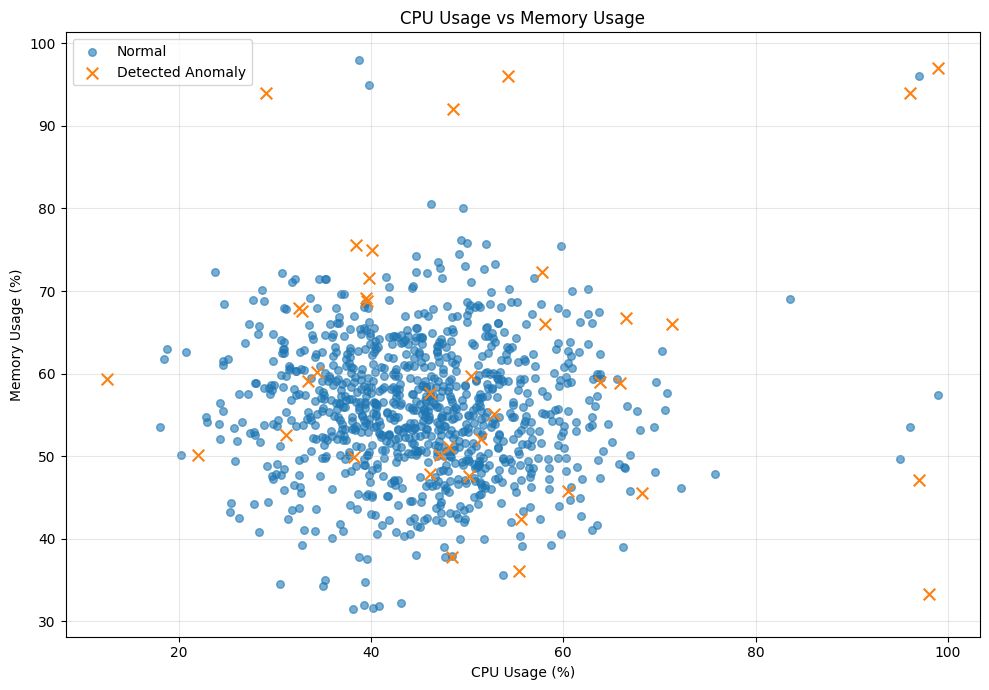

In [ ]:
import matplotlib.pyplot as plt

# Separate normal and anomalous predictions
normal_data = results[results["predicted_anomaly"] == 0]
anomaly_data = results[results["predicted_anomaly"] == 1]

plt.figure(figsize=(10, 7))

# Normal observations
plt.scatter(
    normal_data["cpu_usage"],
    normal_data["memory_usage"],
    label="Normal",
    alpha=0.6,
    s=30
)

# Detected anomalies
plt.scatter(
    anomaly_data["cpu_usage"],
    anomaly_data["memory_usage"],
    label="Detected Anomaly",
    marker="x",
    s=70
)

plt.title("CPU Usage vs Memory Usage")
plt.xlabel("CPU Usage (%)")
plt.ylabel("Memory Usage (%)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Create a clean table of detected anomalies
detected_anomalies = results[
    results["predicted_anomaly"] == 1
].sort_values("anomaly_score")

print("Total detected anomalies:", len(detected_anomalies))

display(
    detected_anomalies[
        [
            "timestamp",
            "cpu_usage",
            "memory_usage",
            "disk_usage",
            "network_usage",
            "active_processes",
            "anomaly_score"
        ]
    ].head(15)
)

Total detected anomalies: 39


,timestamp,cpu_usage,memory_usage,disk_usage,network_usage,active_processes,anomaly_score
200,2026-01-01 03:20:00,48.577874,92.000000,58.043481,31.481404,103.654858,-0.000410
400,2026-01-01 06:40:00,29.055723,94.000000,32.782624,33.931436,107.309579,-0.000397
744,2026-01-01 12:24:00,50.176590,47.581175,14.704399,22.038812,124.065087,-0.000384
83,2026-01-01 01:23:00,39.817298,71.613984,17.038190,21.062508,71.325392,-0.000380
141,2026-01-01 02:21:00,58.071428,66.005655,40.508877,12.982181,124.575396,-0.000371
872,2026-01-01 14:32:00,31.206808,52.535726,19.129730,21.221053,81.331862,-0.000361
323,2026-01-01 05:23:00,65.923873,58.892013,56.744924,32.063808,83.849813,-0.000357
594,2026-01-01 09:54:00,55.375399,36.096541,48.484309,40.073866,99.878302,-0.000331
500,2026-01-01 08:20:00,54.261775,96.000000,45.706130,39.445127,85.618323,-0.000327
305,2026-01-01 05:05:00,46.173274,47.812256,71.099186,38.490968,76.031918,-0.000319


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_true, predicted_anomaly)
precision = precision_score(y_true, predicted_anomaly)
recall = recall_score(y_true, predicted_anomaly)
f1 = f1_score(y_true, predicted_anomaly)

print("=" * 40)
print("FINAL MODEL EVALUATION")
print("=" * 40)

print(f"Total Records       : {len(results)}")
print(f"Actual Anomalies    : {y_true.sum()}")
print(f"Detected Anomalies  : {predicted_anomaly.sum()}")

print("\nPerformance Metrics")
print("-" * 40)
print(f"Accuracy             : {accuracy:.2%}")
print(f"Precision            : {precision:.2%}")
print(f"Recall               : {recall:.2%}")
print(f"F1-Score             : {f1:.2%}")

FINAL MODEL EVALUATION
Total Records       : 1000
Actual Anomalies    : 13
Detected Anomalies  : 39

Performance Metrics
----------------------------------------
Accuracy             : 96.20%
Precision            : 17.95%
Recall               : 53.85%
F1-Score             : 26.92%


In [ ]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

nu_values = [0.01, 0.02, 0.03, 0.05]

results_comparison = []

for nu in nu_values:

    # Create model
    svm_model = OneClassSVM(
        kernel="rbf",
        gamma="auto",
        nu=nu
    )

    # Train
    svm_model.fit(X_scaled)

    # Predict
    pred = svm_model.predict(X_scaled)

    # Convert -1/1 to 1/0
    pred_anomaly = (pred == -1).astype(int)

    # Calculate metrics
    results_comparison.append({
        "nu": nu,
        "Detected Anomalies": pred_anomaly.sum(),
        "Accuracy": accuracy_score(y_true, pred_anomaly),
        "Precision": precision_score(y_true, pred_anomaly),
        "Recall": recall_score(y_true, pred_anomaly),
        "F1 Score": f1_score(y_true, pred_anomaly)
    })

comparison_df = pd.DataFrame(results_comparison)

display(comparison_df)

,nu,Detected Anomalies,Accuracy,Precision,Recall,F1 Score
0,0.01,44,0.957,0.159091,0.538462,0.245614
1,0.02,39,0.962,0.179487,0.538462,0.269231
2,0.03,41,0.960,0.170732,0.538462,0.259259
3,0.05,53,0.956,0.207547,0.846154,0.333333


In [ ]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Use only normal records for training
normal_training_data = X_scaled[y_true == 0]

print("Training records:", len(normal_training_data))
print("Training anomalies:", 0)

# Final One-Class SVM
final_model = OneClassSVM(
    kernel="rbf",
    gamma="auto",
    nu=0.05
)

# Train only on normal data
final_model.fit(normal_training_data)

# Predict on the complete dataset
final_predictions = final_model.predict(X_scaled)

# Convert:
# 1  = normal
# -1 = anomaly
final_predicted_anomaly = (final_predictions == -1).astype(int)

# Evaluate
accuracy = accuracy_score(y_true, final_predicted_anomaly)
precision = precision_score(y_true, final_predicted_anomaly)
recall = recall_score(y_true, final_predicted_anomaly)
f1 = f1_score(y_true, final_predicted_anomaly)

print("\nFINAL MODEL RESULTS")
print("=" * 40)
print("Detected anomalies:", final_predicted_anomaly.sum())
print(f"Accuracy : {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall   : {recall:.2%}")
print(f"F1 Score : {f1:.2%}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, final_predicted_anomaly))

Training records: 987
Training anomalies: 0

FINAL MODEL RESULTS
Detected anomalies: 66
Accuracy : 94.70%
Precision: 19.70%
Recall   : 100.00%
F1 Score : 32.91%

Confusion Matrix:
[[934  53]
 [  0  13]]


In [ ]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Normal data only for training
normal_training_data = X_scaled[y_true == 0]

nu_values = [0.01, 0.02, 0.03, 0.05]

comparison = []

for nu in nu_values:

    # Create model
    svm_model = OneClassSVM(
        kernel="rbf",
        gamma="auto",
        nu=nu
    )

    # Train only on normal observations
    svm_model.fit(normal_training_data)

    # Predict on complete dataset
    predictions = svm_model.predict(X_scaled)

    # Convert -1 = anomaly, 1 = normal
    predicted = (predictions == -1).astype(int)

    # Metrics
    comparison.append({
        "nu": nu,
        "Detected Anomalies": predicted.sum(),
        "Accuracy": accuracy_score(y_true, predicted),
        "Precision": precision_score(y_true, predicted, zero_division=0),
        "Recall": recall_score(y_true, predicted, zero_division=0),
        "F1 Score": f1_score(y_true, predicted, zero_division=0)
    })

comparison_df = pd.DataFrame(comparison)

display(comparison_df)

,nu,Detected Anomalies,Accuracy,Precision,Recall,F1 Score
0,0.01,49,0.964,0.265306,1.0,0.419355
1,0.02,54,0.959,0.240741,1.0,0.388060
2,0.03,52,0.961,0.250000,1.0,0.400000
3,0.05,66,0.947,0.196970,1.0,0.329114


In [ ]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Use only normal data for training
normal_training_data = X_scaled[y_true == 0]

# Final One-Class SVM
final_model = OneClassSVM(
    kernel="rbf",
    gamma="auto",
    nu=0.01
)

# Train the final model
final_model.fit(normal_training_data)

# Predict on complete dataset
final_predictions = final_model.predict(X_scaled)

# Convert predictions
# 1 = Normal
# -1 = Anomaly
final_predicted_anomaly = (final_predictions == -1).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_true, final_predicted_anomaly)
precision = precision_score(
    y_true,
    final_predicted_anomaly,
    zero_division=0
)
recall = recall_score(
    y_true,
    final_predicted_anomaly,
    zero_division=0
)
f1 = f1_score(
    y_true,
    final_predicted_anomaly,
    zero_division=0
)

# Confusion matrix
cm = confusion_matrix(
    y_true,
    final_predicted_anomaly
)

print("=" * 45)
print("FINAL SERVER LOAD ANOMALY DETECTION MODEL")
print("=" * 45)

print(f"Training records       : {len(normal_training_data)}")
print(f"Actual anomalies       : {y_true.sum()}")
print(f"Detected anomalies     : {final_predicted_anomaly.sum()}")

print("\nPerformance Metrics")
print("-" * 45)
print(f"Accuracy               : {accuracy:.2%}")
print(f"Precision              : {precision:.2%}")
print(f"Recall                 : {recall:.2%}")
print(f"F1-Score               : {f1:.2%}")

print("\nConfusion Matrix")
print(cm)

FINAL SERVER LOAD ANOMALY DETECTION MODEL
Training records       : 987
Actual anomalies       : 13
Detected anomalies     : 49

Performance Metrics
---------------------------------------------
Accuracy               : 96.40%
Precision              : 26.53%
Recall                 : 100.00%
F1-Score               : 41.94%

Confusion Matrix
[[951  36]
 [  0  13]]


FINAL RESULTS
Total records: 1000
Actual anomalies: 13
Detected anomalies: 49


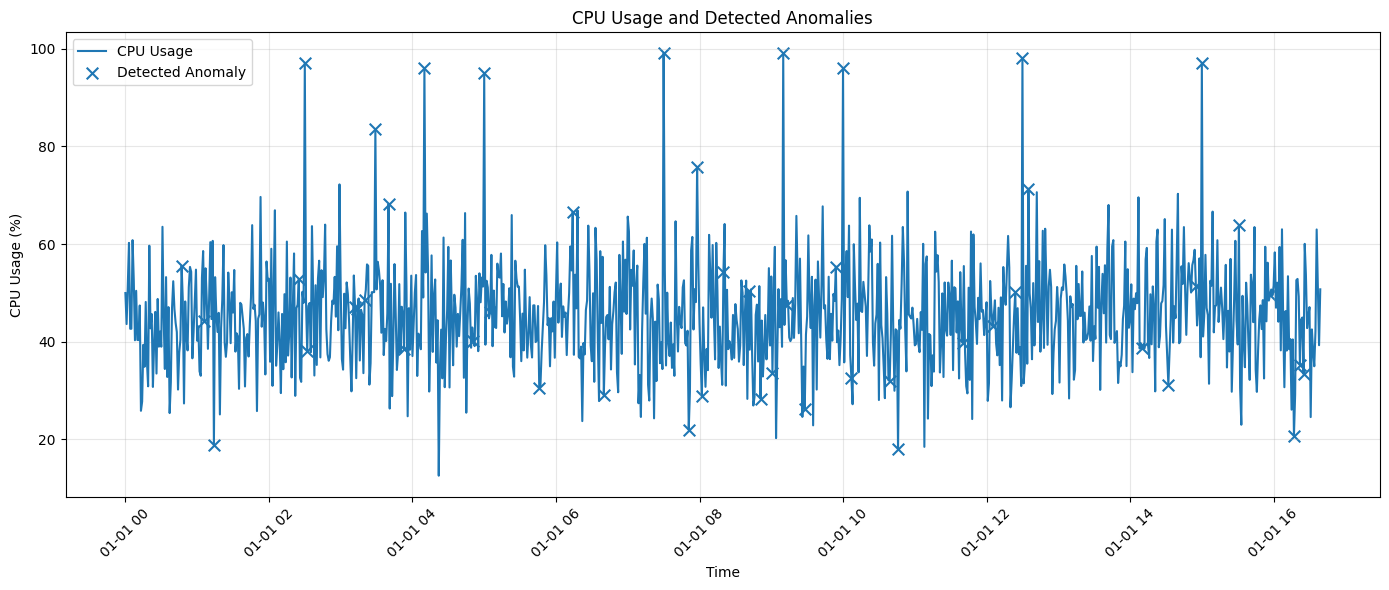

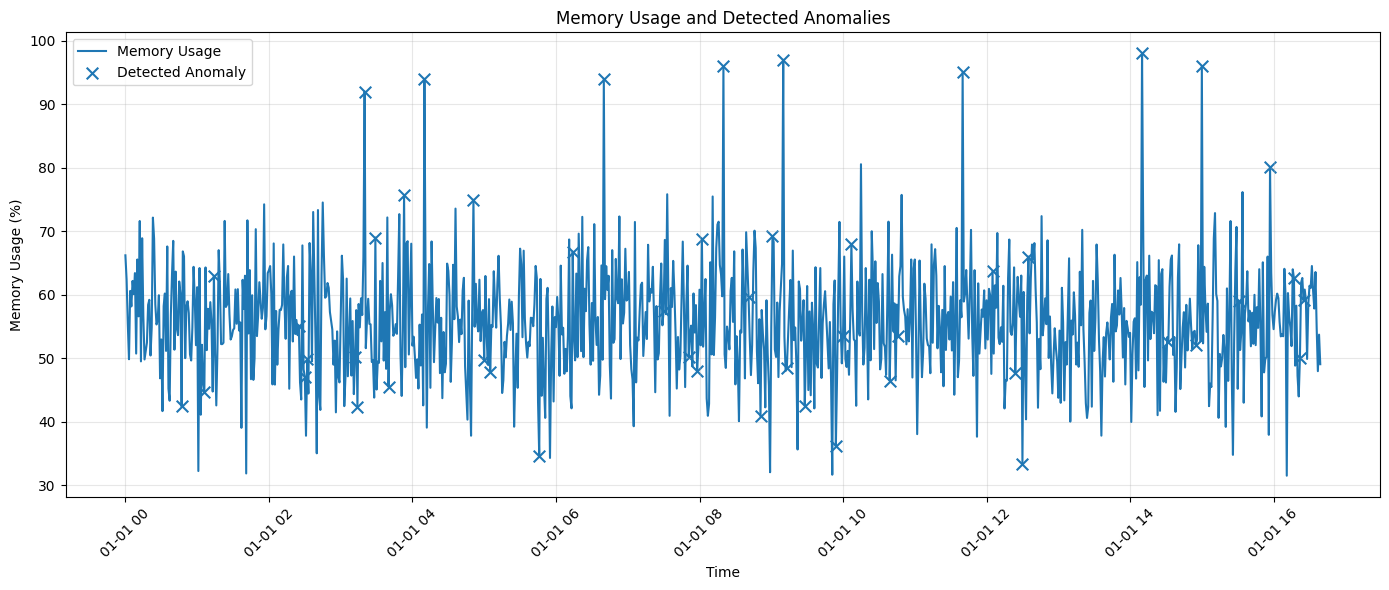

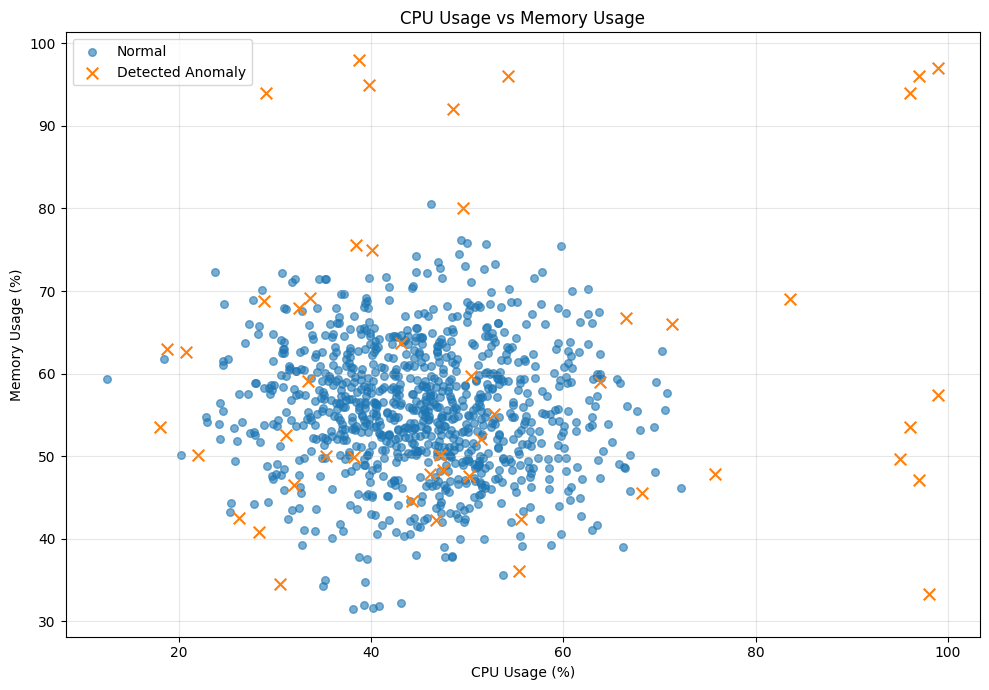

In [ ]:
# Store final predictions in the results DataFrame
results["final_prediction"] = final_predicted_anomaly

# Calculate final anomaly scores
results["final_anomaly_score"] = final_model.decision_function(X_scaled)

# Separate normal and detected anomaly records
final_normal = results[results["final_prediction"] == 0]
final_anomalies = results[results["final_prediction"] == 1]

print("FINAL RESULTS")
print("=" * 40)
print("Total records:", len(results))
print("Actual anomalies:", results["anomaly"].sum())
print("Detected anomalies:", results["final_prediction"].sum())

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    results["timestamp"],
    results["cpu_usage"],
    label="CPU Usage"
)

plt.scatter(
    final_anomalies["timestamp"],
    final_anomalies["cpu_usage"],
    marker="x",
    s=70,
    label="Detected Anomaly"
)

plt.title("CPU Usage and Detected Anomalies")
plt.xlabel("Time")
plt.ylabel("CPU Usage (%)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.figure(figsize=(14, 6))

plt.plot(
    results["timestamp"],
    results["memory_usage"],
    label="Memory Usage"
)

plt.scatter(
    final_anomalies["timestamp"],
    final_anomalies["memory_usage"],
    marker="x",
    s=70,
    label="Detected Anomaly"
)

plt.title("Memory Usage and Detected Anomalies")
plt.xlabel("Time")
plt.ylabel("Memory Usage (%)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 7))

plt.scatter(
    final_normal["cpu_usage"],
    final_normal["memory_usage"],
    label="Normal",
    alpha=0.6,
    s=30
)

plt.scatter(
    final_anomalies["cpu_usage"],
    final_anomalies["memory_usage"],
    label="Detected Anomaly",
    marker="x",
    s=70
)

plt.title("CPU Usage vs Memory Usage")
plt.xlabel("CPU Usage (%)")
plt.ylabel("Memory Usage (%)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
most_anomalous_final = results.sort_values(
    "final_anomaly_score"
).head(10)

display(
    most_anomalous_final[
        [
            "timestamp",
            "cpu_usage",
            "memory_usage",
            "disk_usage",
            "network_usage",
            "active_processes",
            "final_anomaly_score",
            "anomaly",
            "final_prediction"
        ]
    ]
)

,timestamp,cpu_usage,memory_usage,disk_usage,network_usage,active_processes,final_anomaly_score,anomaly,final_prediction
550,2026-01-01 09:10:00,99.000000,97.000000,24.140167,25.748364,120.897719,-0.590782,1,1
750,2026-01-01 12:30:00,98.000000,33.374142,57.554757,25.312579,116.559003,-0.581935,1,1
250,2026-01-01 04:10:00,96.000000,94.000000,38.724509,34.825980,116.130151,-0.569941,1,1
900,2026-01-01 15:00:00,97.000000,96.000000,39.544878,25.551050,94.121849,-0.563347,1,1
850,2026-01-01 14:10:00,38.768595,98.000000,34.517312,25.802701,60.627744,-0.532841,1,1
500,2026-01-01 08:20:00,54.261775,96.000000,45.706130,39.445127,85.618323,-0.450548,1,1
400,2026-01-01 06:40:00,29.055723,94.000000,32.782624,33.931436,107.309579,-0.439645,1,1
700,2026-01-01 11:40:00,39.772770,95.000000,43.868085,38.521376,85.107010,-0.430486,1,1
300,2026-01-01 05:00:00,95.000000,49.655276,50.519476,32.708423,93.646021,-0.422476,1,1
150,2026-01-01 02:30:00,97.000000,47.068861,38.241456,36.735870,99.093944,-0.416889,1,1


In [ ]:
import joblib

joblib.dump(final_model, "server_anomaly_model.pkl")
joblib.dump(scaler, "server_scaler.pkl")

['server_scaler.pkl']

In [ ]:
import joblib

joblib.dump(final_model, "server_anomaly_model.pkl")

['server_anomaly_model.pkl']